# 3-D Acoustic FWI · Overthrust

SEG/EAGE Overthrust is the canonical 3-D land-acquisition benchmark. This notebook ports `examples/FWI/3d/acoustic/torch/fwi_overthrust.py` to a Jupyter-friendly mini run:

1. load the SEG/EAGE Overthrust true and smooth `vp` cubes from `examples/models/overthrust/`
2. downsample aggressively so the experiment fits in a notebook (~1.5 M voxels)
3. lay out a surface shot / receiver grid
4. forward-model observed data through the truth
5. run a short Adam FWI loop on a subset of shots and watch the smooth initial model gain Overthrust's faults and channels

Full-resolution production runs use `epochs=101, batchsize=8` on a multi-GPU box; this version trades that for 12 epochs × 4 shots/epoch on a single GPU so the whole notebook finishes in a few minutes.

## 1. Parameters

In [1]:
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

from sweep.equations import Acoustic3D
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker

MODEL_DIR = Path('../../examples/models/overthrust').resolve()

# Grid / forward modeling — aggressively downsampled for a notebook-friendly run
dh         = 25.0           # m (matches Overthrust native grid)
dt         = 2e-3
nt         = 1500
fm         = 8.0
delay      = 0.30
spatial_order = 4
abcn       = 10

# How much we downsample the 187 × 801 × 801 native Overthrust cube
stride_z, stride_y, stride_x = 2, 8, 8     # → (94, 101, 101) ≈ 0.96 M voxels

# Acquisition — coarse so the experiment is fast
src_step   = 32
rec_step   = 8
src_margin = 12
rec_margin = 4
srcz, recz = 1, 1

# FWI
lr          = 20.0
epochs      = 12
batchsize   = 4               # shots per Adam step
show_every  = 4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## 2. Load and downsample the Overthrust models

In [2]:
def load_cube(name):
    full = np.load(MODEL_DIR / name).astype(np.float32)
    return np.ascontiguousarray(full[::stride_z, ::stride_y, ::stride_x])

true_model = load_cube('true_3d.npy')
init_model = load_cube('smooth_3d.npy')
shape = true_model.shape
nz, ny, nx = shape
print('downsampled cube shape (nz, ny, nx):', shape)
print('vp range — true  :', true_model.min(), '–', true_model.max())
print('vp range — smooth:', init_model.min(), '–', init_model.max())

downsampled cube shape (nz, ny, nx): (94, 101, 101)
vp range — true  : 2182.338 – 6000.0
vp range — smooth: 2505.8389 – 6000.0


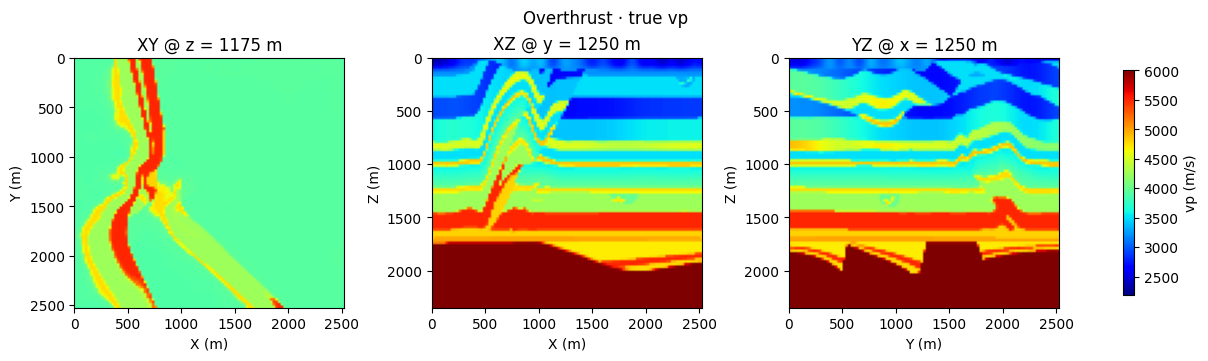

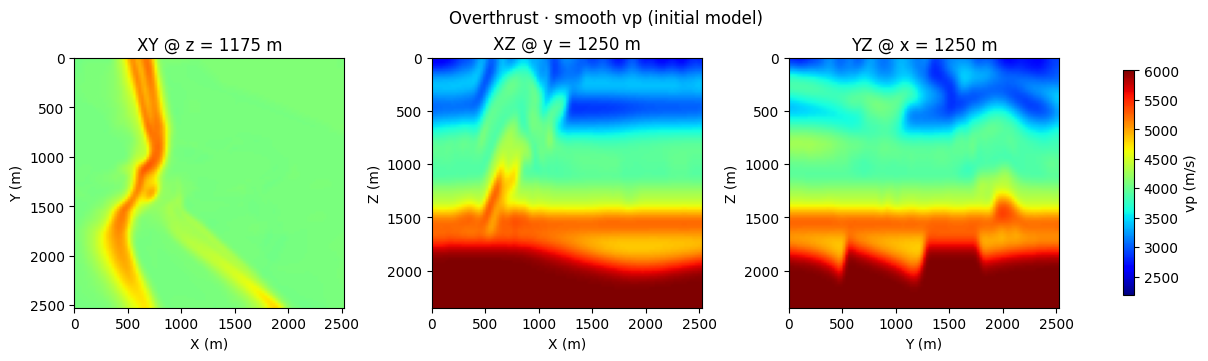

In [3]:
def show_cube(volume, title, vmin=None, vmax=None):
    if vmin is None: vmin = volume.min()
    if vmax is None: vmax = volume.max()
    slices = [
        (volume[nz // 2], f'XY @ z = {nz // 2 * dh:.0f} m', 'X (m)', 'Y (m)', [0, nx * dh, ny * dh, 0]),
        (volume[:, ny // 2, :], f'XZ @ y = {ny // 2 * dh:.0f} m', 'X (m)', 'Z (m)', [0, nx * dh, nz * dh, 0]),
        (volume[:, :, nx // 2], f'YZ @ x = {nx // 2 * dh:.0f} m', 'Y (m)', 'Z (m)', [0, ny * dh, nz * dh, 0]),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), constrained_layout=True)
    for ax, (data, t, xl, yl, ext) in zip(axes, slices):
        im = ax.imshow(data, vmin=vmin, vmax=vmax, cmap='jet', aspect='auto', extent=ext)
        ax.set_title(t); ax.set_xlabel(xl); ax.set_ylabel(yl)
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.9, label='vp (m/s)')
    fig.suptitle(title)
    plt.show()

vmin, vmax = float(true_model.min()), float(true_model.max())
show_cube(true_model, 'Overthrust · true vp', vmin, vmax)
show_cube(init_model, 'Overthrust · smooth vp (initial model)', vmin, vmax)

## 3. Build the solver

In [4]:
equation = Acoustic3D(spatial_order=spatial_order, device=device)
solver = PropTorch(
    equation, shape=shape, dh=dh, dt=dt, nt=nt, dev=device,
    source_type=['h1'], receiver_type=['h1'],
    abcn=abcn, impl='eager', use_ckpt=True, ckpt_chunks=16,
)

### Aside · which sources and receivers does this equation accept?

`Acoustic3D` publishes a structured field table — query `eq.models` for the
expected model input order, `available_source_fields()` / `available_receiver_fields()`
for valid source / receiver options. See the
[Equations user guide](../../user-guide/equations/) for the full rundown.

In [5]:
print('models (input order matters!):')
for spec in equation.MODEL_SPECS:
    unit = f' [{spec.unit}]' if spec.unit else ''
    print(f'  - {spec.name:8s}{unit}  — {spec.description}')
print('defaults  :', equation.default_source_fields, '/', equation.default_receiver_fields)
print('receivers :')
for spec in equation.available_receiver_fields():
    print(f'  - {spec.name:8s} aliases={spec.aliases}  — {spec.description}')

models (input order matters!):
  - vp       [m/s]  — 3D acoustic P-wave velocity model.
defaults  : ['h1'] / ['h1']
receivers :
  - h1       aliases=('pressure', 'p')  — Primary 3D acoustic pressure-like wavefield.


## 4. Acquisition geometry — surface shot grid + dense receiver grid

9 shots, 144 receivers/shot
sources shape:   (9, 3)
receivers shape: (9, 144, 3)


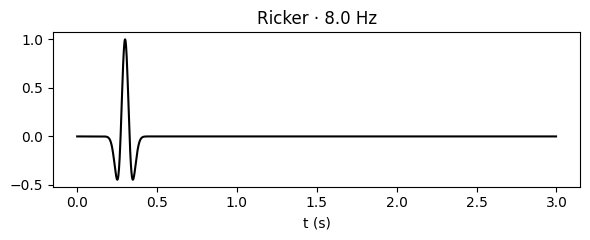

In [6]:
src_x = np.arange(src_margin, nx - src_margin, src_step, dtype=np.int64)
src_y = np.arange(src_margin, ny - src_margin, src_step, dtype=np.int64)
sxg, syg = np.meshgrid(src_x, src_y, indexing='xy')
sources = np.stack([sxg.ravel(), syg.ravel(),
                    np.full(sxg.size, srcz, dtype=np.int64)], axis=-1)

rec_x = np.arange(rec_margin, nx - rec_margin, rec_step, dtype=np.int64)
rec_y = np.arange(rec_margin, ny - rec_margin, rec_step, dtype=np.int64)
rxg, ryg = np.meshgrid(rec_x, rec_y, indexing='xy')
one_shot_receivers = np.stack([rxg.ravel(), ryg.ravel(),
                               np.full(rxg.size, recz, dtype=np.int64)], axis=-1)
receivers = np.broadcast_to(one_shot_receivers, (sources.shape[0], *one_shot_receivers.shape)).copy()

nshots = sources.shape[0]
nrec = one_shot_receivers.shape[0]
print(f'{nshots} shots, {nrec} receivers/shot')
print('sources shape:  ', sources.shape)
print('receivers shape:', receivers.shape)

t = np.arange(nt, dtype=np.float32) * dt
wavelet = ricker(t - delay, f=fm).astype(np.float32)
plt.figure(figsize=(6, 2.5))
plt.plot(t, wavelet, color='black'); plt.xlabel('t (s)'); plt.title(f'Ricker · {fm} Hz')
plt.tight_layout(); plt.show()

## 5. Observed data — forward modeling through the true vp

Run shots one at a time (the receiver grid is large; batching whole shots inflates memory).

observed data shape: (9, 1500, 144, 1)


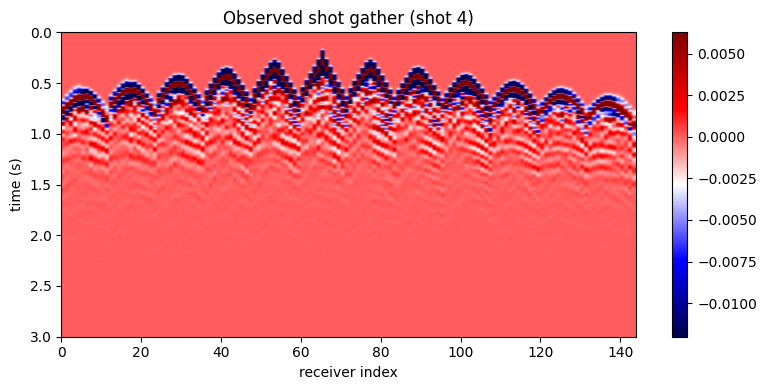

In [7]:
true_vp = torch.from_numpy(true_model).to(device)
obs_list = []
with torch.no_grad():
    for s in range(nshots):
        rec = solver(wavelet, sources[s:s+1], receivers[s:s+1], models=[true_vp])
        obs_list.append(rec.detach().cpu())
obs = torch.cat(obs_list, dim=0).numpy()
print('observed data shape:', obs.shape)  # (nshots, nt, nrec, nfields)

# show one shot gather (collapse the receiver grid down to a 1-D index)
shot_idx = nshots // 2
gather = obs[shot_idx].squeeze()
if gather.shape[0] != nt:
    gather = gather.T
vmin_g, vmax_g = np.percentile(gather, [2, 98])
plt.figure(figsize=(8, 4))
plt.imshow(gather, cmap='seismic', vmin=vmin_g, vmax=vmax_g, aspect='auto',
           extent=[0, gather.shape[1], nt * dt, 0])
plt.xlabel('receiver index'); plt.ylabel('time (s)')
plt.title(f'Observed shot gather (shot {shot_idx})')
plt.colorbar(); plt.tight_layout(); plt.show()

## 6. FWI loop — Adam, mini-batched shots

In [8]:
torch.manual_seed(0)
np.random.seed(0)

inv_vp = torch.from_numpy(init_model).to(device).requires_grad_(True)
obs_torch = torch.from_numpy(obs)
opt = torch.optim.Adam([inv_vp], lr=lr, eps=1e-22)

losses = []
for epoch in range(epochs):
    opt.zero_grad()
    shot_idx = np.random.choice(nshots, size=min(batchsize, nshots), replace=False)
    total_loss = 0.0
    for s in shot_idx:
        syn = solver(wavelet, sources[s:s+1], receivers[s:s+1], models=[inv_vp])
        obs_b = obs_torch[s:s+1].to(device)
        loss = (syn - obs_b).pow(2).sum()
        loss.backward()
        total_loss += float(loss.detach())
    opt.step()
    losses.append(total_loss)
    if epoch % show_every == 0 or epoch == epochs - 1:
        print(f'  epoch {epoch:3d}  loss {total_loss:.4e}')

inv_vp_np = inv_vp.detach().cpu().numpy()

  epoch   0  loss 7.4271e+01


  epoch   4  loss 4.5380e+01


  epoch   8  loss 3.0445e+01


  epoch  11  loss 1.9640e+01


## 7. Inverted vp and loss curve

Three orthogonal slices through the same cube positions used for the truth + a log-scale loss curve. After only 12 epochs × 4 shots/epoch the result is far from converged, but you can already see structure leaking back into the smooth initial model — channels in the XY slice, dipping reflectors in XZ.

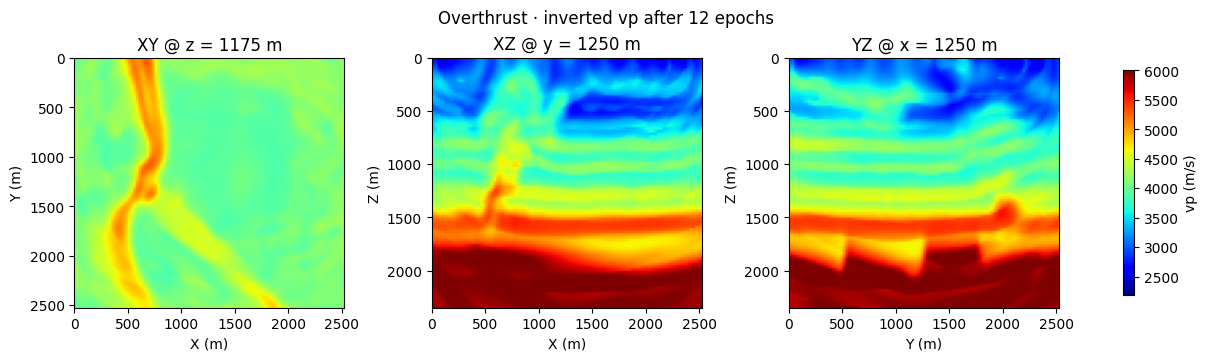

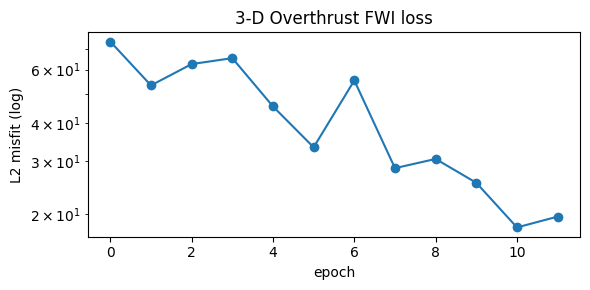

In [9]:
show_cube(inv_vp_np, f'Overthrust · inverted vp after {epochs} epochs', vmin, vmax)

plt.figure(figsize=(6, 3))
plt.semilogy(losses, marker='o')
plt.xlabel('epoch'); plt.ylabel('L2 misfit (log)')
plt.title('3-D Overthrust FWI loss')
plt.tight_layout(); plt.show()

---

<p><strong>Download this notebook</strong> &mdash; <a href="11_fwi_acoustic_overthrust_3d.ipynb" download><code>11_fwi_acoustic_overthrust_3d.ipynb</code></a> &middot; or <a href="https://github.com/DeepWave-KAUST/sweep/blob/dev/examples/notebooks/11_fwi_acoustic_overthrust_3d.ipynb">view on GitHub</a></p>